# TC CSArs Calanna, PhD
<h1 style="color:red!important">SOCIAL NETWORK ANALYSIS: CORSO INTRODUTTIVO</h1>

### DATASET IMPIEGATO: Zachary karate club
Zachary, W. W. (1977). An Information Flow Model for Conflict and Fission in Small Groups. Journal of Anthropological Research, 33(4), 452–473. http://www.jstor.org/stable/3629752

# PROGRAMMA

- <b>INTRO</b>: definizione e sue strutture fondamentali
- <b>ESERCITAZIONE</b>
  - descrizione network - layout del network
  - descrizione network - struttura macro
  - descrizione network - struttura micro
  - descrizione network - struttura meso
  -descrizione network - modello previsionale

In [1]:
# imports
import numpy as np
import pandas as pd
import networkx as nx
import networkx.algorithms.connectivity as nxconn
from networkx.algorithms import community as nxcomm
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
NODE_SIZE=500
SEED = 42

BASE_OPTIONS = {
    "node_size": NODE_SIZE,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 1,
    "width": 1,
}

# INTRO

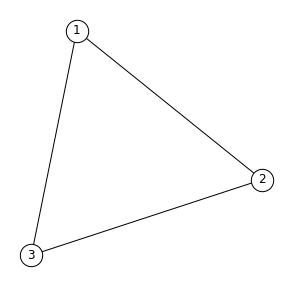

In [3]:
# undirected
fig, ax = plt.subplots(figsize=(5,5))
ax.axis('off')

Gu = nx.Graph()
Gu.add_edges_from([(1,2),(2,3),(3,1)])
pos = nx.spring_layout(Gu, k=.3, seed=SEED)

nx.draw_networkx(Gu,pos,**BASE_OPTIONS);

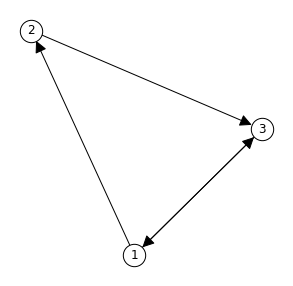

In [4]:
# directed
fig, ax = plt.subplots(figsize=(5,5))
ax.axis('off')

Gd = nx.DiGraph()
Gd.add_edges_from([(1,2),(2,3),(3,1),(1,3)])
pos = nx.spring_layout(Gd, k=.3, seed=SEED)
options = dict(**BASE_OPTIONS)
options.update({ "arrowsize": 25 })
nx.draw_networkx(Gd,pos,**options);

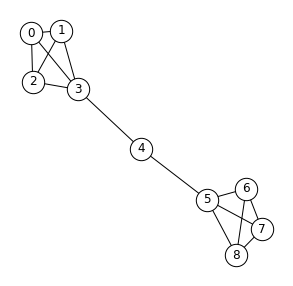

In [87]:
# BARBELL
fig, ax = plt.subplots(figsize=(5,5))
ax.axis('off')

Gb = nx.barbell_graph(4,1)
pos = nx.spring_layout(Gb, k=.5, seed=SEED)
nx.draw_networkx(Gb,pos, **BASE_OPTIONS)

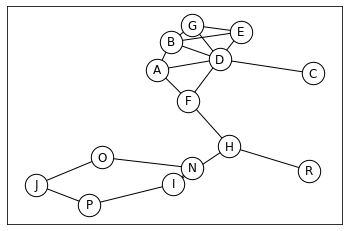

In [14]:
Ge = nx.Graph()
Ge.add_edges_from([
    ("A","D"),("A","F"),("A","B"),
    ("B","E"),("E","G"),("G","D"),
    ("G","B"),("B","D"),("D","F"),
    ("E","D"),("C","D"),("H","F"),
    ("H","I"),("R","H"),("I","P"),
    ("I","N"),("N","O"),("O","J"),
    ("J","P"),
])
pos = nx.spring_layout(Ge, k=.5, seed=SEED)
nx.draw_networkx(Ge, pos, **BASE_OPTIONS)

In [99]:
# Degree Centrality
sorted(dict(nx.betweenness_centrality(Gb)).items(), key=lambda x: x[1], reverse=True)

[(4, 0.5714285714285714),
 (3, 0.5357142857142857),
 (5, 0.5357142857142857),
 (0, 0.0),
 (1, 0.0),
 (2, 0.0),
 (6, 0.0),
 (7, 0.0),
 (8, 0.0)]

# ESERCITAZIONE

In [5]:
# constants
G = nx.karate_club_graph()
CL = nx.circular_layout(G)
SL = nx.spring_layout(G, seed=SEED)

#################################################
# NODI RILEVANTI
#################################################
MRHI = 0 # allenatore
OFFICER = 33 # presidente del club
#################################################

In [6]:
nx.info(G)

'Graph named "Zachary\'s Karate Club" with 34 nodes and 78 edges'

## 1. VISUALIZZAZIONE DEL NETWORK

### 1.1 LAYOUT CIRCOLARE

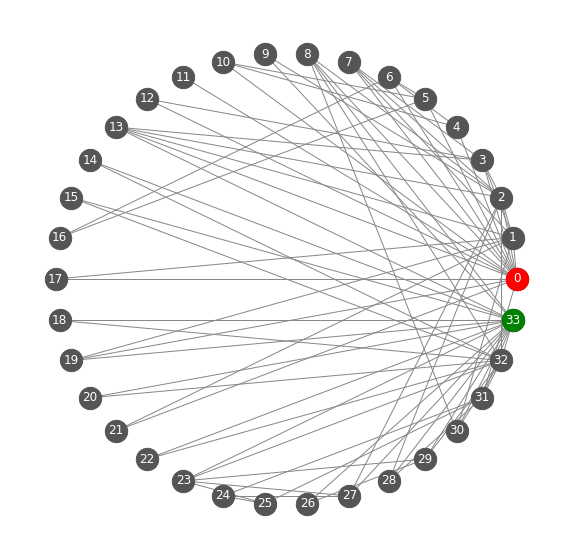

In [7]:
fig, ax = plt.subplots(figsize=(10,10))
ax.axis('off')

nx.draw_networkx_nodes(
    G,CL, nodelist=G.nodes(), node_size=NODE_SIZE, node_color= "#555", edgecolors="#555", ax=ax)
nx.draw_networkx_nodes(
    G,CL, nodelist=[MRHI],node_size=NODE_SIZE, node_color= "r", edgecolors="r", ax=ax)
nx.draw_networkx_nodes(
    G,CL, nodelist=[OFFICER], node_size=NODE_SIZE, node_color= "g", edgecolors="g", ax=ax)
nx.draw_networkx_labels(
    G,CL, font_color="#fff")
nx.draw_networkx_edges(G,CL,edge_color="#888");

### 1.2 LAYOUT SPRING

In [8]:
def plot_default_spring(G,pos):
    fig, ax = plt.subplots(figsize=(10,10))
    ax.axis('off')
    nx.draw_networkx_nodes(
        G,SL, nodelist=G.nodes(), node_size=NODE_SIZE, node_color= "#fff", edgecolors="k", ax=ax)
    nx.draw_networkx_edges(G,SL, edge_color="#888")
    nx.draw_networkx_labels(G,SL)
    return (fig, ax)

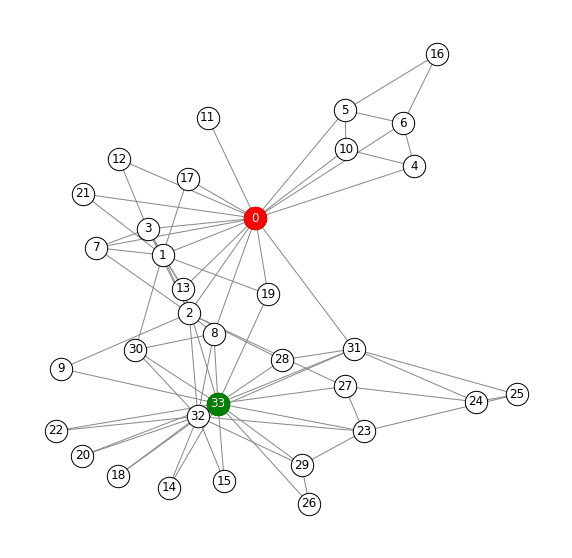

In [36]:
fig, ax = plot_default_spring(G,SL)

# highlight MRHI AND OFFICER
nx.draw_networkx_nodes(
    G,SL, nodelist=[MRHI],node_size=NODE_SIZE, node_color= "r", edgecolors="r", ax=ax)
nx.draw_networkx_nodes(
    G,SL, nodelist=[OFFICER], node_size=NODE_SIZE, node_color= "g", edgecolors="g", ax=ax);
nx.draw_networkx_labels(G, SL, labels={OFFICER:OFFICER,MRHI:MRHI}, font_color="#fff");

### 1.3 LAYOUT SPRING PONDERATO

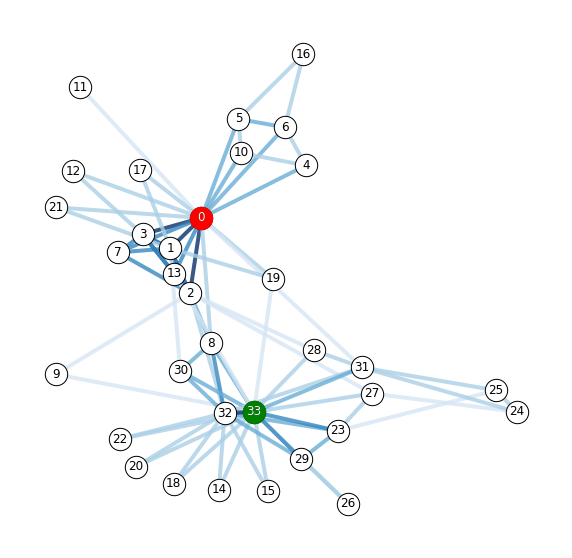

In [38]:
fig, ax = plt.subplots(figsize=(10,10))
ax.axis('off')

def tie_strength(G, v, w):
    v_neighbors = set(G.neighbors(v))
    w_neighbors = set(G.neighbors(w))
    return 1 + len(v_neighbors & w_neighbors)

weigths = dict(map(lambda e: (e, tie_strength(G, *e)), G.edges))
nx.set_edge_attributes(G, weigths,"weight")
edge_weights = nx.get_edge_attributes(G, "weight").values()

weighted_pos = nx.spring_layout(G, pos=SL, k=0.3, weight="weight")

nx.draw_networkx_nodes(
    G, weighted_pos, node_size=NODE_SIZE, node_color="#fff", edgecolors="k", ax=ax)

nx.draw_networkx_nodes(
    G,weighted_pos, nodelist=[MRHI],node_size=NODE_SIZE, node_color= "r", edgecolors="r", ax=ax)

nx.draw_networkx_nodes(
    G,weighted_pos, nodelist=[OFFICER], node_size=NODE_SIZE, node_color= "g", edgecolors="g", ax=ax)

nx.draw_networkx_edges(G, weighted_pos, width=4,
    edge_color=edge_weights, edge_cmap=plt.cm.Blues,
    edge_vmin=0, edge_vmax=6, alpha=.8, ax=ax)

nx.draw_networkx_labels(G, weighted_pos);
nx.draw_networkx_labels(G, weighted_pos, labels={OFFICER:OFFICER,MRHI:MRHI}, font_color="#fff");

## 2. DESCRITTIVE: macro-struttura

### 2.1 Diameter
the diameter of a connected graph is the maximum length of a shortest path. That is, it is the maximum of the distances between pairs of vertices in the graph. If the graph has weights on its edges, then its weighted diameter measures path length by the sum of the edge weights along a path, while the unweighted diameter measures path length by the number of edges. For disconnected graphs, definitions vary: the diameter may be defined as infinite, or as the largest diameter of a connected component, or it may be undefined.

In [11]:
diameter = nx.diameter(G)
f"diametro del network: {diameter}"

'diametro del network: 5'

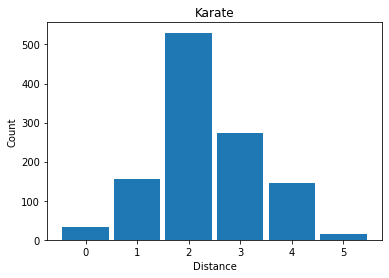

In [12]:
# DISTRIBUZIONE DELLA LUNGHEZZA DEI PERCORSI
def crawl(o):
    if type(o) is dict:
        return crawl(o.values())
    return list(o)

def path_length_histogram(G, title=None):
    length_source_target = dict(nx.shortest_path_length(G))
    all_shortest = sum(map(crawl, length_source_target.values()),[])
    high = max(all_shortest)
    bins = [-0.5 + i for i in range(high + 2)]
    plt.hist(all_shortest, bins=bins, rwidth=.9)
    plt.title(title)
    plt.xlabel("Distance")
    plt.ylabel("Count")

path_length_histogram(G, title="Karate")

In [13]:
# PERCORSI PIU' LUNGHI
df = pd.DataFrame(nx.shortest_path(G)).applymap(lambda x: len(x))
df["max"] = df.max(axis=1)
df.sort_values(by="max", ascending=False)\
    .head(10)\
    .style.highlight_max(color = 'lightgreen', axis=1, subset=df.columns[:-1])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,max
26,4,4,4,4,5,5,5,5,3,3,5,5,5,3,3,3,6,5,3,3,3,5,3,3,4,4,1,3,3,2,3,3,3,2,6
29,4,4,3,4,5,5,5,4,3,3,5,5,5,3,3,3,6,5,3,3,3,5,3,2,4,3,2,3,3,1,3,3,2,2,6
22,4,4,3,4,5,5,5,4,3,3,5,5,5,3,3,3,6,5,3,3,3,5,1,3,4,4,3,3,3,3,3,3,2,2,6
20,4,4,3,4,5,5,5,4,3,3,5,5,5,3,3,3,6,5,3,3,1,5,3,3,4,4,3,3,3,3,3,3,2,2,6
18,4,4,3,4,5,5,5,4,3,3,5,5,5,3,3,3,6,5,1,3,3,5,3,3,4,4,3,3,3,3,3,3,2,2,6
15,4,4,3,4,5,5,5,4,3,3,5,5,5,3,3,1,6,5,3,3,3,5,3,3,4,4,3,3,3,3,3,3,2,2,6
14,4,4,3,4,5,5,5,4,3,3,5,5,5,3,1,3,6,5,3,3,3,5,3,3,4,4,3,3,3,3,3,3,2,2,6
23,4,4,3,4,5,5,5,4,3,3,5,5,5,3,3,3,6,5,3,3,3,5,3,1,3,2,3,2,3,2,3,3,2,2,6
16,3,4,4,4,3,2,2,4,4,5,3,4,4,4,6,6,1,4,6,4,6,4,6,6,5,5,6,5,5,6,5,4,5,5,6
9,3,3,2,3,4,4,4,3,3,1,4,4,4,3,3,3,5,4,3,3,3,4,3,3,4,4,3,3,3,3,3,3,3,2,5


[[29, 32, 2, 0, 5, 16],
 [29, 32, 8, 0, 5, 16],
 [29, 33, 8, 0, 5, 16],
 [29, 32, 31, 0, 5, 16],
 [29, 33, 31, 0, 5, 16],
 [29, 33, 13, 0, 5, 16],
 [29, 33, 19, 0, 5, 16],
 [29, 32, 2, 0, 6, 16],
 [29, 32, 8, 0, 6, 16],
 [29, 33, 8, 0, 6, 16],
 [29, 32, 31, 0, 6, 16],
 [29, 33, 31, 0, 6, 16],
 [29, 33, 13, 0, 6, 16],
 [29, 33, 19, 0, 6, 16]]

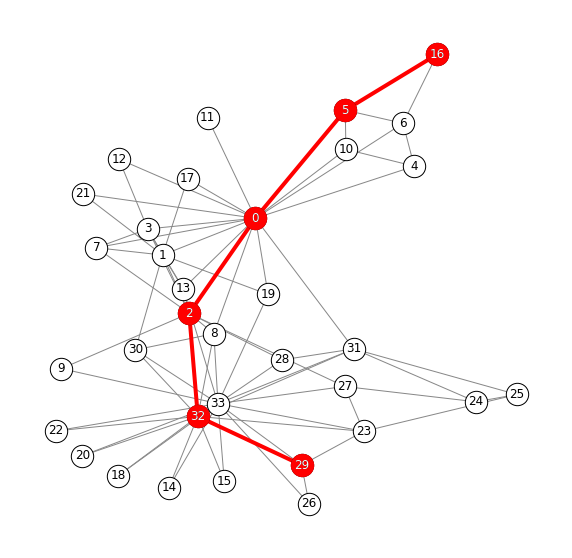

In [14]:
# ESEMPIO DI PERCORSO LUNGO
fig, ax = plot_default_spring(G,SL);

s_node = 29
t_node = 16

possible_sp = list(nx.all_shortest_paths(G,s_node, t_node))

display(possible_sp)

first_sp = possible_sp[0]
first_sp_edges = [ (x, first_sp[idx+1]) for idx,x in enumerate(first_sp[:-1]) ]

nx.draw_networkx_nodes(
    G, SL, nodelist=first_sp, node_size=NODE_SIZE, node_color= "r", edgecolors="r", ax=ax)
nx.draw_networkx_edges(G, SL, edgelist=first_sp_edges, edge_color="r", width=4, ax=ax)
nx.draw_networkx_labels(G, SL, labels=dict([(e,e) for e in first_sp]), font_color="#fff");

### 2.2 DENSITY
In a graph of n nodes, the density is the ratio of the number of edges of the graph to the number of edges in a complete graph on n nodes.

In [15]:
density = nx.density(G)
f"density: {density}"

'density: 0.13903743315508021'

### 2.3 CENTRALIZATION

In [16]:
def get_centralization(G):
    n = G.order()
    centrality_values = dict(G.degree()).values()
    c_max = max(centrality_values)
    return sum([ c_max - value for value in centrality_values ]) / ((n-1)*(n-2))

f"centralizzazione: {get_centralization(G)}"

'centralizzazione: 0.3996212121212121'

'centralizzazione: 1.0'

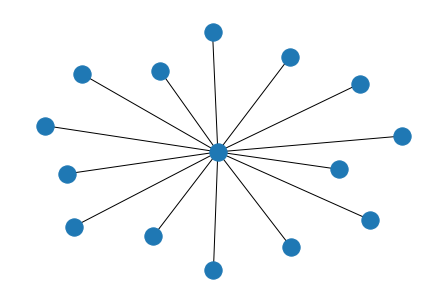

In [17]:
# ESEMPIO DI CENTRALIZATION MASSIMA
S = nx.Graph()
S.add_nodes_from(range(15))
nx.add_star(S, S.nodes())
loc = nx.spring_layout(S)
nx.draw(S,loc)

f"centralizzazione: {get_centralization(S)}"

'centralizzazione: 0.0'

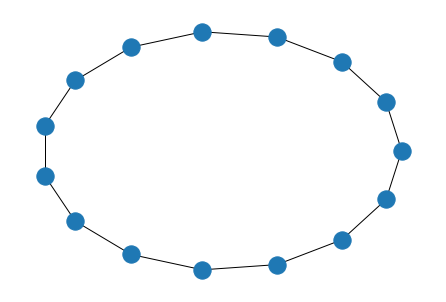

In [18]:
# ESEMPIO DI CENTRALIZATION MINIMA
C = nx.Graph()
nodes = range(15)
C.add_nodes_from(nodes)
C.add_edges_from(
    sum([[(x,nodes[idx+1]) for idx,x in enumerate(nodes[:-1])], [(nodes[0], nodes[-1])]], [])
)
loc = nx.circular_layout(C)
nx.draw(C,loc)

f"centralizzazione: {get_centralization(C)}"

### 2.4 GLOBAL CLUSTERING

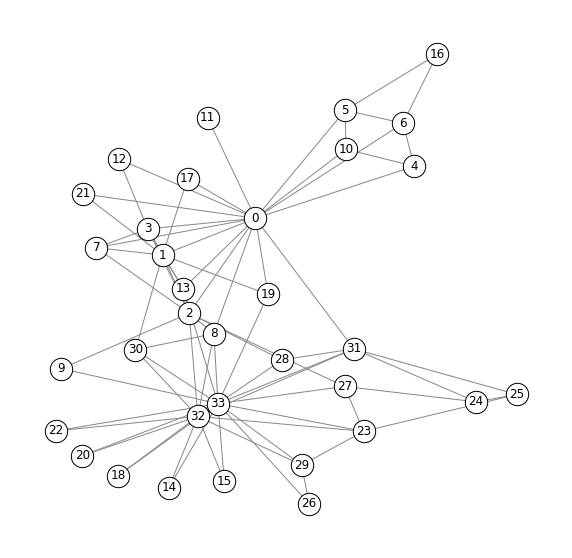

In [19]:
fig, ax = plot_default_spring(G,SL)

In [20]:
global_clustering = nx.average_clustering(G)

f"global clustering: {global_clustering}"
nx.transitivity(G)

0.2556818181818182

'global clustering: 1.0'

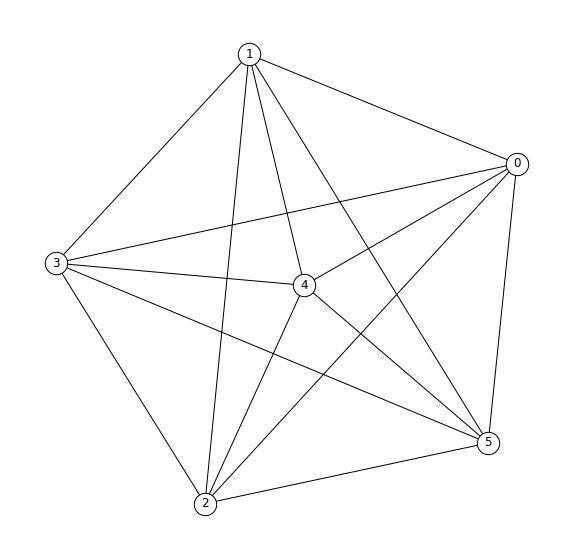

In [21]:
# ESEMPIO DI NETWORK COMPLETO
fig, ax = plt.subplots(figsize=(10,10))
ax.axis('off')

G_complete = nx.complete_graph(6)
loc = nx.spring_layout(G_complete)
nx.draw_networkx_nodes(G_complete, loc, ax=ax, node_size=NODE_SIZE, node_color="#fff", edgecolors="k")
nx.draw_networkx_edges(G_complete, loc, ax=ax)
nx.draw_networkx_labels(G_complete, loc);

f"global clustering: {nx.average_clustering(G_complete)}"

# 2. DESCRITTIVE: micro-strutture

<b>Degree cenrality</b> the number of links incident upon a node (i.e., the number of ties that a node has)

In [22]:
highest_dc = [ n for n,v in sorted(list(nx.degree(G)), key=lambda e: e[1])[-10:]]
f"I 10 nodi con più alta dc: {highest_dc}"

'I 10 nodi con più alta dc: [8, 13, 23, 3, 31, 1, 2, 32, 0, 33]'

<b>Bridge</b>:  a bridge, isthmus, cut-edge, or cut arc is an edge of a graph whose deletion increases the graph's number of connected components.

In [23]:
bridges = list(nx.bridges(G))
f"bridges: {bridges}"

'bridges: [(0, 11)]'

In [24]:
# proof
G_clone = G.copy()
cc_before = len(list(nx.connected_components(G_clone)))
display(f"connected components before bridge removal: {cc_before}")
G_clone.remove_edge(*bridges[0])
cc_after = len(list(nx.connected_components(G_clone)))
display(f"connected components before bridge removal: {cc_after}")

'connected components before bridge removal: 1'

'connected components before bridge removal: 2'

# 3. DESCRITTIVE: meso-strutture

### Ricerca comunità (Clauset-Newman-Moore greedy modularity maximization)

In [25]:
communities = sorted(nxcomm.greedy_modularity_communities(G), key=len)

f"{len(communities)} comunità trovate"

'3 comunità trovate'

In [26]:
(c1, c2, c3) = nxcomm.greedy_modularity_communities(G)

display(f"C1: {c1}")
display(f"C2: {c2}")
display(f"C3: {c3}")

'C1: frozenset({8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33})'

'C2: frozenset({1, 2, 3, 7, 9, 12, 13, 17, 21})'

'C3: frozenset({0, 16, 19, 4, 5, 6, 10, 11})'

In [27]:
c1_with_c2 = set(sum([list(G.neighbors(n)) for n in c2], [])).intersection(c1)
c1_with_c3 = set(sum([list(G.neighbors(n)) for n in c3], [])).intersection(c1)
c2_with_c3 = set(sum([list(G.neighbors(n)) for n in c3], [])).intersection(c2)

display(f"nodi di collegamento C1 e C2 {c1_with_c2}")
display(f"nodi di collegamento C1 e C3 {c1_with_c3}")
display(f"nodi di collegamento C2 e C3 {c2_with_c3}")

'nodi di collegamento C1 e C2 {32, 33, 8, 27, 28, 30}'

'nodi di collegamento C1 e C3 {8, 33, 31}'

'nodi di collegamento C2 e C3 {1, 2, 3, 7, 12, 13, 17, 21}'

In [28]:
c1_with_c2 = set(sum([list(G.neighbors(n)) for n in c2], [])).intersection(c1)
c1_with_c3 = set(sum([list(G.neighbors(n)) for n in c3], [])).intersection(c1)
c2_with_c3 = set(sum([list(G.neighbors(n)) for n in c3], [])).intersection(c2)

display(f"nodi di collegamento C1 e C2 {c1_with_c2}")
display(f"nodi di collegamento C1 e C3 {c1_with_c3}")
display(f"nodi di collegamento C2 e C3 {c2_with_c3}")

'nodi di collegamento C1 e C2 {32, 33, 8, 27, 28, 30}'

'nodi di collegamento C1 e C3 {8, 33, 31}'

'nodi di collegamento C2 e C3 {1, 2, 3, 7, 12, 13, 17, 21}'

In [29]:
comm_officer = list(c1)
comm_mrhi = list(c2) + list(c3)

e_0 = [0 if G.nodes()[n]['club'] == "Mr. Hi" else 1 for n in comm_mrhi]
e_1 = [0 if G.nodes()[n]['club'] == "Officer" else 1 for n in comm_officer]

hit_perc = 1 - sum((e_0 + e_1))/G.order()

f"percentuale di successo: {hit_perc}"

display(c1, c2, c3)

frozenset({8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33})

frozenset({1, 2, 3, 7, 9, 12, 13, 17, 21})

frozenset({0, 4, 5, 6, 10, 11, 16, 19})

# 4. MODELLO PREVISIONALE

## Scisma

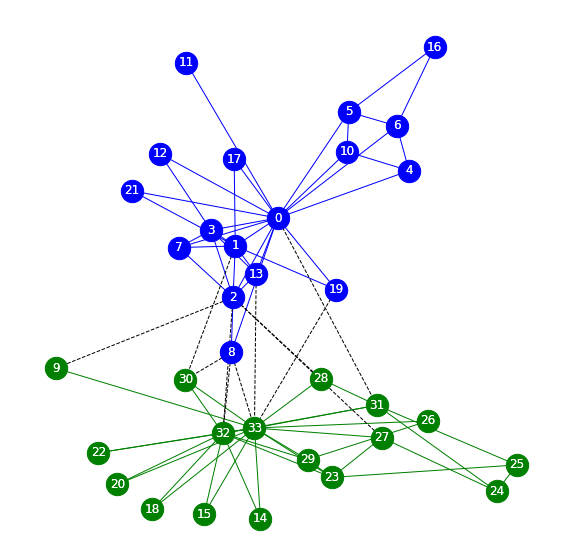

In [30]:
loc = nx.spring_layout(G, seed=42)
node_size=500

fig, ax = plt.subplots(figsize=(10,10))
ax.axis('off')

for color, club in [("b","Mr. Hi" ), ("g", 'Officer')]:
    nodes = [ n for n,d in G.nodes(data=True) if d["club"] == club ]
    edges = [ e for e in G.edges() if e[0] in nodes and e[1] in nodes ]
    nx.draw_networkx_nodes(
        G, loc, nodelist=nodes, node_color=color, edgecolors=color, node_size=node_size, ax=ax)
    nx.draw_networkx_edges(G, loc, edgelist=edges, edge_color=color, ax=ax)
    nx.draw_networkx_labels(G, loc, font_color="#fff", ax=ax);

connection_edges = [e for e in G.edges() if G.nodes()[e[0]]['club'] !=  G.nodes()[e[1]]['club']]
nx.draw_networkx_edges(G, loc, edgelist=connection_edges, edge_color="k", style="--", ax=ax);